<a href="https://colab.research.google.com/github/whiterabbit077/st554_hw7/blob/main/HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title:** Homework #7  
**Class:** ST-554 Big Data  
**Date:** 3/31/2026  
**Author:** Anna Giczewska

#Part I - Concepts

**1. Five V's of Big Data: Apple Watch Data**
1.   **Volume**: tons of measurements per user (heart rate samples, steps, stand minutes, workout metrics, sleep data), multiplied across millions of Apple Watch users.

2.   **Velocity**: data is captured continuously or frequently (heart rate during the day/workouts, activity rings updating in near real time, notifications/alerts generated quickly).

3.   **Variety**: heart rate, HRV, ECG (supported models), blood oxygen (supported models), sleep stages, steps/distance, calories, workouts (pace, splits, elevation), fall detection events, GPS routes, plus context like timestamps, device model, and user-entered info (age, weight, medications if tracked).

4.   **Veracity**: readings can be noisy or missing (loose band, motion during workouts, tattoos/skin contact issues, cold weather affecting sensors, battery dead/not worn), differences across models/watchOS versions, and user-input errors (incorrect age/weight).

5.   **Value**: personalized insights (Activity trends, fitness/sleep coaching), safety/health alerts (irregular rhythm notifications, fall detection), sharing with clinicians/research (if user opts in), and long-term tracking to spot changes over time.



**2. CRUD examples in the Lahman MLB database context**
1.   **C (Create)**: INSERT a new row into a table (e.g., add a new Team season record).

2.   **R (Read)**: SELECT teams from 2015.

3.   **U (Update)**: UPDATE a row (e.g., fix a player's birth city if it was wrong).

4.   **D (Delete)**: DELETE a row (e.g., remove a duplicate record you inserted by mistake).


**3. Purpose of HAVING**

HAVING filters groups after a GROUP BY (it's like WHERE, but for aggregate results). Example idea: "return teams with SUM(W) > 90" - that condition has to go in HAVING, not WHERE.


#Part II - Simulation of the sampling distribution of the slope

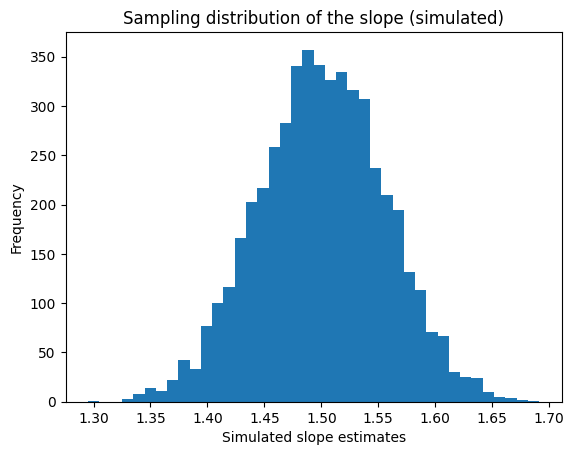

Estimated P(b1_hat > 1.65) = 0.0032


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1) Set seed so results are repeatable
np.random.seed(32)

# 2) True model parameters
beta0 = 7
beta1 = 1.5

# 3) Make x values: 0,1,2,...,10 repeated 3 times (total 33 points)
x = np.repeat(np.arange(0, 11), 3)   # length 33
n = len(x)

# 4) Simulation settings
B = 5000
slopes = []

# sklearn needs x as a column (2D)
X = x.reshape(-1, 1)

# 5) Run simulations
for i in range(B):
    # generate random noise (sigma^2 = 1 so sigma = 1)
    eps = np.random.normal(0, 1, n)
    y = beta0 + beta1 * x + eps

    # fit linear regression and save slope
    model = LinearRegression()
    model.fit(X, y)
    slopes.append(model.coef_[0])

slopes = np.array(slopes)

# 6) Plot histogram of slopes
plt.hist(slopes, bins=40)
plt.xlabel("Simulated slope estimates")
plt.ylabel("Frequency")
plt.title("Sampling distribution of the slope (simulated)")
plt.show()

# 7) Estimate probability that slope > 1.65
prob = np.mean(slopes > 1.65)
print("Estimated P(b1_hat > 1.65) =", prob)

**Interpretation:** We simulated data where the true slope is $\beta_{1} = 1.5$, so the histogram shows what slope estimates $\hat{\beta}_{1}$ look like just from random noise when $H_{0}: \beta_{1} = 1.5$ is true. The value $P(\hat{\beta}_{1} > 1.65)$ is the right-tail probability under $H_{0}$, which is the same kind of probability used for a one-sided p-value if your observed slope was $1.65$ (or bigger).

#Part III - Simulation of the sampling distribution of the slope

**5. Bias in ML models article**

***Example:*** An image recognition model associated "kitchens" with women because the training images often showed women cooking/cleaning.

***Issue around the data:*** the training set reflected a stereotyped/unbalanced distribution (more women pictured in kitchens than men), so the model learned that bias and reproduced it.

***How to augment/account for bias:*** collect/label additional images with men in kitchens and women outside kitchen contexts to balance representation, evaluate model errors by subgroup.


**6. Earth Sciences big data article**

**Topic: Oceanography.**

**Summary:** Big data comes from expanding sensor networks and platforms (satellites + in-ocean sensors/floats/autonomous vehicles), producing massive, continuously growing datasets used to understand ocean structure and processes and to improve models and “digital twins” ideas.

**Possible biases:**

*   spatial gaps (fewer sensors in remote/polar regions or deep ocean),
*   measurement bias (different instruments with different calibration/accuracy),
*   "convenience sampling" where data are easier/cheaper to collect,
*   uneven temporal coverage (storms/winter conditions reduce observations).









**7. Rare events**

Example: cybersecurity breaches (major breaches are rare but extremely costly). Understanding the tail risk helps with budgeting, insurance, and setting security controls.


#Part IV - SQL with Lahman.db

In [ ]:
#Q8

import os
import urllib.request
import sqlite3
import pandas as pd

DB_URL = "https://github.com/jknecht/baseball-archive-sqlite/releases/download/2022/lahman_1871-2022.sqlite"
DB_FILE = "lahman.sqlite"

# Download only if we don't already have it
if not os.path.exists(DB_FILE):
    print("Downloading database file...")
    urllib.request.urlretrieve(DB_URL, DB_FILE)

# Connect
conn = sqlite3.connect(DB_FILE)

# Sanity check: list tables
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name;
""", conn)

tables.head(20)

,name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


In [ ]:
#Q9: all teams that played in 2015

q9 = pd.read_sql("""
SELECT *
FROM Teams
WHERE yearID = 2015;
""", conn)

q9

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


In [ ]:
#Q10: Hall of fame players and year voted in and category

q10 = pd.read_sql("""
SELECT playerID, yearID, category
FROM HallOfFame
WHERE inducted = 'Y';
""", conn)
q10

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


In [ ]:
#Q11: unique managers of Pittsburgh Pirate

q11 = pd.read_sql("""
SELECT DISTINCT playerID
FROM Managers
WHERE teamID = 'PIT';
""", conn)
q11

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


In [ ]:
#Q12: playerIDs who managed AND were inducted

q12 = pd.read_sql("""
SELECT DISTINCT m.playerID
FROM Managers AS m
JOIN HallOfFame AS h
  ON m.playerID = h.playerID
WHERE h.inducted = 'Y';
""", conn)

q12_count = q12["playerID"].nunique()
q12, q12_count

(     playerID
 0   alstowa01
 1   andersp01
 2   ansonca01
 3   applilu01
 4   baineha01
 ..        ...
 92  willidi02
 93  willite01
 94  wrighge01
 95  wrighha01
 96  youngcy01
 
 [97 rows x 1 columns],
 97)

In [ ]:
#Q13: seasons managed by HOF managers

seasons = pd.read_sql("""
SELECT m.playerID, m.G, m.W, m.L
FROM Managers AS m
JOIN HallOfFame AS h
  ON m.playerID = h.playerID
WHERE h.inducted = 'Y';
""", conn)

# Overall record per manager
summary = seasons.groupby("playerID")[["W", "L"]].sum().reset_index()
summary["win_pct"] = summary["W"] / (summary["W"] + summary["L"])
summary = summary.sort_values(by="win_pct", ascending=False)

print(seasons.head())
print(summary.head(20))

    playerID    G   W   L
0  alstowa01  154  92  62
1  alstowa01  154  98  55
2  alstowa01  154  93  61
3  alstowa01  154  84  70
4  alstowa01  154  71  83
     playerID     W     L   win_pct
75  simmote01     1     0  1.000000
94  wrighge01    59    25  0.702381
78  spaldal01    78    47  0.624000
57  mccarjo99  2125  1333  0.614517
19  comisch01   840   541  0.608255
74  seleefr99  1284   862  0.598322
77  southbi01  1044   704  0.597254
13  chancfr01   946   648  0.593476
59  mcgrajo01  2763  1948  0.586500
51  lopezal01  1410  1004  0.584093
90  weaveea99  1480  1060  0.582677
16  cochrmi01   348   250  0.581940
95  wrighha01  1225   885  0.580569
2   ansonca01  1296   947  0.577798
14  clarkfr01  1602  1181  0.575638
89   wardjo01   412   320  0.562842
0   alstowa01  2040  1613  0.558445
58  mccarto01    15    12  0.555556
21    coxbo01  2497  1999  0.555383
42  huggimi01  1413  1134  0.554770
